# Forest LULC — DL Ensemble: New Image Prediction

Applies a previously trained ResU-Net + MAnet softmax averaging ensemble
to a new Sentinel-1 + Sentinel-2 image for a different date range.

**Run order:** Cell 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8

**Prerequisites (files on Google Drive):**
- `model1_best.pth`, `model2_best.pth` — trained model weights
- `band_min.npy`, `band_max.npy` — normalisation stats from training
- `class_mapping.json` — class id → name lookup
- `study_area.gpkg` — study area boundary

All four model files are uploaded automatically when you run the training notebook.

In [1]:
# CELL 1 -- Install
!pip install earthengine-api geemap geopandas fiona rasterio segmentation-models-pytorch scikit-image scipy -q


In [2]:
# CELL 2 -- Imports
import os, io, json, time
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.features import shapes as rasterio_shapes
from pathlib import Path

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload
import ee

from shapely.geometry import shape as shapely_shape
from skimage.morphology import disk
from skimage.filters.rank import majority as majority_filter_sk
from scipy.ndimage import label as nd_label, distance_transform_edt

print('Imports OK')
print(f'GPU available: {torch.cuda.is_available()}')


Imports OK
GPU available: True


In [3]:
# CELL 3 -- CONFIG
# Edit start_date / end_date and export_prefix for each new prediction run.

NI_CFG = {
    'gee_project':    'data-pipeline-1-464218',

    # Study area GeoPackage already in your Drive folder
    'gpkg_filename':  'phase2.gpkg',
    'gpkg_layer':     'phase2',

    # Date range to predict -- change this each run
    'start_date':   '2025-11-01',
    'end_date':     '2026-05-29',
    'cloud_thresh':   20,

    # Export settings -- must match the training feature stack
    'export_crs':     'EPSG:32630',
    'export_scale':   10,
    'drive_folder':   'Forest_LULC_Classification',
    'export_prefix':  'phase2_s1_s2_features_new',

    # Architecture -- must match training CONFIG
    'model_1_type':    'resunet',
    'model_1_encoder': 'resnet50',
    'n_bands':         26,
    'patch_size':      256,
    'patch_stride':    128,

    # Post-processing
    'majority_radius': 2,
    'mmu_pixels':      100,
    'simplify_tol':    10,

    # Local scratch
    # Auto-detects Colab (/content) vs Lightning AI vs local machine
    'local_dir':   (_BASE := Path('/content') if Path('/content').exists() else
                   Path('/teamspace/studios/this_studio') if Path('/teamspace').exists() else
                   Path.home()) / 'Forest_LULC_Classification',
    'output_dir':  _BASE / 'Forest_LULC_Classification/NewImage_Results',
    'dl_dir':      _BASE / 'Forest_LULC_Classification/DL_Results',
}

for d in ('local_dir', 'output_dir', 'dl_dir'):
    NI_CFG[d].mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('CONFIG loaded')
print(f'  Date range : {NI_CFG["start_date"]} to {NI_CFG["end_date"]}')
print(f'  Export     : {NI_CFG["export_prefix"]}.tif')
print(f'  Device     : {DEVICE}')


CONFIG loaded
  Date range : 2025-11-01 to 2026-05-29
  Export     : phase2_s1_s2_features_new.tif
  Device     : cuda


In [4]:
# CELL 4 -- GEE auth, Drive API, and helper functions
#
# NEW SESSION  -> uncomment ee.Authenticate(), run, paste the code, comment back.
# SAME SESSION -> leave it commented.

# ee.Authenticate(auth_mode='notebook')  # <- uncomment for a new session
ee.Initialize(project=NI_CFG['gee_project'])

_creds_path = os.path.expanduser('~/.config/earthengine/credentials')
with open(_creds_path) as _f:
    _cd = json.load(_f)
_drive_creds = Credentials(
    token=None, refresh_token=_cd['refresh_token'],
    token_uri='https://oauth2.googleapis.com/token',
    client_id=_cd['client_id'], client_secret=_cd['client_secret'],
    scopes=['https://www.googleapis.com/auth/drive']
)
_drive_creds.refresh(Request())
_drive_svc = build('drive', 'v3', credentials=_drive_creds)
print('GEE + Drive API ready')


def _folder_id(name=None):
    name = name or NI_CFG['drive_folder']
    res  = _drive_svc.files().list(
        q=f"name='{name}' and mimeType='application/vnd.google-apps.folder' and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"Drive folder '{name}' not found.")
    return res['files'][0]['id']


def drive_download(filename, dest_dir=None, subfolder=None):
    # Searches: subfolder -> Drive root folder -> global Drive.
    dest_dir = Path(dest_dir or NI_CFG['local_dir'])
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest = dest_dir / filename
    if dest.exists():
        print(f'   Already local: {filename}')
        return str(dest)

    def _file_in(parent_id):
        r = _drive_svc.files().list(
            q=f"name='{filename}' and '{parent_id}' in parents and trashed=false",
            fields='files(id)'
        ).execute()
        return r['files'][0]['id'] if r['files'] else None

    file_id = None
    if subfolder:
        root = _folder_id()
        sub  = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{root}' in parents and "
              f"mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        if sub['files']:
            file_id = _file_in(sub['files'][0]['id'])
    if file_id is None:
        file_id = _file_in(_folder_id())
    if file_id is None:
        res = _drive_svc.files().list(
            q=f"name='{filename}' and trashed=false",
            fields='files(id)', spaces='drive'
        ).execute()
        if res['files']:
            file_id = res['files'][0]['id']
            print(f'   Found via global search: {filename}')
    if file_id is None:
        raise FileNotFoundError(
            f"'{filename}' not found. Upload it to "
            f"Drive/{NI_CFG['drive_folder']}/ and retry."
        )
    req = _drive_svc.files().get_media(fileId=file_id)
    with io.FileIO(str(dest), 'wb') as fh:
        dl = MediaIoBaseDownload(fh, req)
        done = False
        while not done:
            _, done = dl.next_chunk()
    print(f'   Downloaded: {filename}')
    return str(dest)


def drive_upload(local_path, subfolder=None):
    local_path = Path(local_path)
    parent     = _folder_id()
    if subfolder:
        res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{parent}' in parents and "
              f"mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        parent = res['files'][0]['id'] if res['files'] else _drive_svc.files().create(
            body={'name': subfolder,
                  'mimeType': 'application/vnd.google-apps.folder',
                  'parents': [parent]},
            fields='id'
        ).execute()['id']
    existing = _drive_svc.files().list(
        q=f"name='{local_path.name}' and '{parent}' in parents and trashed=false",
        fields='files(id)'
    ).execute()
    media = MediaFileUpload(str(local_path), resumable=True)
    if existing['files']:
        _drive_svc.files().update(
            fileId=existing['files'][0]['id'], media_body=media).execute()
    else:
        _drive_svc.files().create(
            body={'name': local_path.name, 'parents': [parent]},
            media_body=media, fields='id'
        ).execute()
    print(f'   Uploaded: {local_path.name}')


def _mask_s2_clouds(image):
    scl  = image.select('SCL')
    mask = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10)).Not()
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

def _apply_speckle_filter(image):
    vv = image.select('VV').focal_mean(radius=5, kernelType='square', units='pixels').rename('VV')
    vh = image.select('VH').focal_mean(radius=5, kernelType='square', units='pixels').rename('VH')
    return image.addBands(vv, None, True).addBands(vh, None, True)

def build_gee_features(study_area_ee, start_date, end_date, cloud_thresh=20):
    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area_ee).filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_thresh))
        .map(_mask_s2_clouds).median().clip(study_area_ee)
    )
    bands = s2.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
    NDVI  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
    NDWI  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
    NDRE  = s2.normalizedDifference(['B8','B5']).rename('NDRE')
    EVI   = s2.expression('2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4'), 'BLUE': s2.select('B2')}).rename('EVI')
    SAVI  = s2.expression('1.5*(NIR-RED)/(NIR+RED+0.5)',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4')}).rename('SAVI')
    NBR   = s2.normalizedDifference(['B8','B12']).rename('NBR')
    BSI   = s2.expression('((SWIR+RED)-(NIR+BLUE))/((SWIR+RED)+(NIR+BLUE))',
        {'SWIR': s2.select('B11'), 'RED': s2.select('B4'),
         'NIR':  s2.select('B8'),  'BLUE': s2.select('B2')}).rename('BSI')
    s1 = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(study_area_ee).filterDate(start_date, end_date)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .map(_apply_speckle_filter)
    )
    mean   = s1.select(['VV','VH']).mean().rename(['VV_mean','VH_mean'])
    mn     = s1.select(['VV','VH']).min().rename(['VV_min','VH_min'])
    mx     = s1.select(['VV','VH']).max().rename(['VV_max','VH_max'])
    std    = s1.select(['VV','VH']).reduce(ee.Reducer.stdDev()).rename(['VV_std','VH_std'])
    ratio  = mean.select('VH_mean').divide(mean.select('VV_mean')).rename('VH_VV_ratio')
    s1_feat = mean.addBands(mn).addBands(mx).addBands(std).addBands(ratio).clip(study_area_ee)
    return (bands.addBands(NDVI).addBands(NDWI).addBands(NDRE)
            .addBands(EVI).addBands(SAVI).addBands(NBR).addBands(BSI).addBands(s1_feat))

print('Helper functions defined')


GEE + Drive API ready
Helper functions defined


In [5]:
# CELL 5 -- Load trained models from Drive

# Download weights and normalisation stats
ckpt1     = drive_download('model1_best.pth', dest_dir=NI_CFG['dl_dir'], subfolder='DL_Results')
bmin_path = drive_download('band_min.npy',    dest_dir=NI_CFG['dl_dir'], subfolder='DL_Results')
bmax_path = drive_download('band_max.npy',    dest_dir=NI_CFG['dl_dir'], subfolder='DL_Results')
band_min  = np.load(bmin_path)
band_max  = np.load(bmax_path)
print(f'Normalisation stats: {len(band_min)} bands')

# Load class mapping
mapping_path = drive_download('class_mapping.json')
with open(mapping_path) as _f:
    _raw = json.load(_f)
id_to_name   = {int(k): v for k, v in _raw.items()}

# Apply the same two class drops used during training
_DROP_NAMES = {'Road buffer', 'Cedrella'}
_name_to_id = {v: k for k, v in id_to_name.items()}
_drop_ids   = {_name_to_id[n] for n in _DROP_NAMES if n in _name_to_id}
_remaining  = sorted(k for k in id_to_name if k not in _drop_ids)
_remap      = {old: new for new, old in enumerate(_remaining)}
id_to_name  = {_remap[old]: id_to_name[old] for old in _remaining}

CLASS_NAMES  = [id_to_name[i] for i in range(len(id_to_name))]
CLASS_COLORS = [mcolors.to_hex(plt.cm.tab10(i % 10)) for i in range(len(CLASS_NAMES))]
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

# Build model architecture and load weights
def _build_model(model_type, encoder):
    kw = dict(encoder_name=encoder, encoder_weights='imagenet',
              in_channels=NI_CFG['n_bands'], classes=NUM_CLASSES, activation=None)
    if model_type == 'unet':      return smp.Unet(**kw)
    if model_type == 'resunet':   return smp.UnetPlusPlus(**kw)
    if model_type == 'attention': return smp.MAnet(**kw)
    raise ValueError(f'Unknown model_type: {model_type}')

model1 = _build_model(NI_CFG['model_1_type'], NI_CFG['model_1_encoder']).to(DEVICE)
model1.load_state_dict(torch.load(ckpt1, map_location=DEVICE))
model1.eval()

print(f'Model 1 ready: {NI_CFG["model_1_type"]} / {NI_CFG["model_1_encoder"]}')


   Already local: model1_best.pth
   Already local: band_min.npy
   Already local: band_max.npy
Normalisation stats: 26 bands
   Already local: class_mapping.json
Classes (9): ['Cocoa', 'Degraded Forest', 'Dense Forest', 'Farms', 'Galamsey', 'Invasives', 'Natural Forest', 'Open Areas', 'Swamp']


Model 1 ready: resunet / resnet50


In [11]:
# CELL 5 -- Build new feature stack on GEE and export to Drive
# Typical runtime: 5-20 min. Skip this cell if the TIF is already on Drive.

gpkg_local = drive_download(NI_CFG['gpkg_filename'])
sa_gdf     = gpd.read_file(gpkg_local, layer=NI_CFG['gpkg_layer']).to_crs('EPSG:4326').dissolve()
sa_geom    = sa_gdf.geometry.iloc[0]
sa_ee      = ee.Geometry(json.loads(sa_gdf.to_json())['features'][0]['geometry'])
print(f'Study area bbox: {sa_geom.bounds}')

feature_image = build_gee_features(
    sa_ee, NI_CFG['start_date'], NI_CFG['end_date'], NI_CFG['cloud_thresh']
)

prefix = NI_CFG['export_prefix']
task   = ee.batch.Export.image.toDrive(
    image=feature_image.toFloat(), description=prefix,
    folder=NI_CFG['drive_folder'], fileNamePrefix=prefix,
    region=sa_ee, scale=NI_CFG['export_scale'], crs=NI_CFG['export_crs'],
    maxPixels=1e13, fileFormat='GeoTIFF'
)
task.start()
print('GEE export submitted -- waiting...')
while task.active():
    print(f'   Status: {task.status()["state"]}    ', end=chr(13))
    time.sleep(20)
state = task.status()['state']
print(f'Final state: {state}')
if state != 'COMPLETED':
    raise RuntimeError(f'GEE export failed: {task.status().get("error_message")}')
print('OK Export complete -- run Cell 6 to predict.')


   Downloaded: phase2.gpkg
Study area bbox: (-3.0574147106421714, 6.272986982975165, -2.4308664012846344, 7.033360256578054)
GEE export submitted -- waiting...


KeyboardInterrupt: 

In [6]:
# CELL 7 -- Download feature stack (handles tiled exports), normalise, and predict

import tempfile, os, gc

prefix = NI_CFG['export_prefix']

def _find_drive_files(name_contains, subfolder_id=None):
    parent = subfolder_id or _folder_id()
    res = _drive_svc.files().list(
        q=f"name contains '{name_contains}' and '{parent}' in parents "
          f"and trashed=false and mimeType!='application/vnd.google-apps.folder'",
        fields='files(id, name)', orderBy='name'
    ).execute()
    return res['files']

tile_files = _find_drive_files(prefix)
if not tile_files:
    res = _drive_svc.files().list(
        q=f"name contains '{prefix}' and trashed=false "
          f"and mimeType!='application/vnd.google-apps.folder'",
        fields='files(id, name)', spaces='drive', orderBy='name'
    ).execute()
    tile_files = res['files']

if not tile_files:
    raise FileNotFoundError(
        f"No files found matching '{prefix}' on Drive. "
        "Run Cell 6 first to export the feature stack."
    )

tile_files = [f for f in tile_files if f['name'].endswith('.tif')]
print(f'Found {len(tile_files)} tile(s):')
for f in tile_files:
    print(f'  {f["name"]}')

tile_paths = []
for f in tile_files:
    dest = NI_CFG['local_dir'] / f['name']
    if not dest.exists():
        req = _drive_svc.files().get_media(fileId=f['id'])
        with io.FileIO(str(dest), 'wb') as fh:
            dl = MediaIoBaseDownload(fh, req)
            done = False
            while not done:
                _, done = dl.next_chunk()
        print(f'   Downloaded: {f["name"]}')
    else:
        print(f'   Already local: {f["name"]}')
    tile_paths.append(str(dest))

# Merge tiles to disk -- never load entire array into RAM
merged_path = str(NI_CFG['local_dir'] / (prefix + '_merged.tif'))
if len(tile_paths) == 1:
    merged_path = tile_paths[0]
    with rasterio.open(merged_path) as src:
        meta = src.meta.copy()
    print(f'Single tile: {merged_path}')
else:
    datasets = [rasterio.open(p) for p in tile_paths]
    _nodata = datasets[0].nodata
    if _nodata is None and datasets[0].dtypes[0].startswith('float'):
        _nodata = float('nan')
    merged, out_transform = rio_merge(datasets, nodata=_nodata)
    meta = datasets[0].meta.copy()
    meta.update({'height': merged.shape[1], 'width': merged.shape[2],
                 'transform': out_transform, 'dtype': 'float32'})
    for ds in datasets:
        ds.close()
    with rasterio.open(merged_path, 'w', **meta) as dst:
        dst.write(merged.astype(np.float32))
    del merged
    gc.collect()
    print(f'{len(tile_paths)} tiles merged -> {prefix}_merged.tif')

# Normalise band-by-band (only 1 band in RAM at a time)
norm_path = str(NI_CFG['local_dir'] / (prefix + '_norm.tif'))
norm_meta = meta.copy()
norm_meta['dtype'] = 'float32'
with rasterio.open(merged_path) as src:
    ni_H, ni_W = src.height, src.width
    with rasterio.open(norm_path, 'w', **norm_meta) as dst:
        for b in range(src.count):
            band = src.read(b + 1).astype(np.float32)
            band = np.nan_to_num(band, nan=0.0, posinf=0.0, neginf=0.0)
            rng = float(band_max[b]) - float(band_min[b])
            band = (band - float(band_min[b])) / rng if rng > 0 else np.zeros_like(band)
            dst.write(band, b + 1)
print(f'Shape: (26, {ni_H}, {ni_W})  -- normalised TIF written')

# score_map on disk via memmap (avoids ~6 GB RAM)
PATCH_SIZE   = NI_CFG['patch_size']
PATCH_STRIDE = NI_CFG['patch_stride']
_stmp = tempfile.NamedTemporaryFile(suffix='.dat', delete=False,
                                     dir=str(NI_CFG['local_dir']))
_stmp.close()
score_map = np.memmap(_stmp.name, dtype='float32', mode='w+',
                      shape=(NUM_CLASSES, ni_H, ni_W))
count_map  = np.zeros((ni_H, ni_W), dtype=np.float32)

r_steps = range(0, ni_H - PATCH_SIZE + 1, PATCH_STRIDE)
c_steps = range(0, ni_W - PATCH_SIZE + 1, PATCH_STRIDE)
total   = len(r_steps) * len(c_steps)
done    = 0
print('Predicting with ResU-Net / ResNet50...')

with rasterio.open(norm_path) as src_norm:
    with torch.no_grad():
        for r in r_steps:
            strip = src_norm.read(
                window=rasterio.windows.Window(0, r, ni_W, PATCH_SIZE)
            ).astype(np.float32)  # (n_bands, PATCH_SIZE, ni_W)
            for c in c_steps:
                patch = torch.tensor(
                    strip[:, :, c:c+PATCH_SIZE]
                ).unsqueeze(0).to(DEVICE)
                probs = F.softmax(model1(patch), dim=1).squeeze(0).cpu().numpy()
                score_map[:, r:r+PATCH_SIZE, c:c+PATCH_SIZE] += probs
                count_map[    r:r+PATCH_SIZE, c:c+PATCH_SIZE] += 1
                done += 1
                if done % 50 == 0:
                    print(f'   {done/total*100:.0f}%', end='\r')

# Aggregate in strips to avoid a full (NUM_CLASSES, H, W) array in RAM
count_map = np.where(count_map == 0, 1, count_map)
pred_map  = np.zeros((ni_H, ni_W), dtype=np.uint8)
entropy   = np.zeros((ni_H, ni_W), dtype=np.float32)
for rs in range(0, ni_H, 512):
    re  = min(rs + 512, ni_H)
    avg = score_map[:, rs:re, :] / count_map[np.newaxis, rs:re, :]
    pred_map[rs:re, :] = avg.argmax(axis=0).astype(np.uint8)
    p = np.clip(avg, 1e-10, 1.0)
    entropy[rs:re, :] = -np.sum(p * np.log(p), axis=0)

del score_map
os.unlink(_stmp.name)
gc.collect()
print('OK  Full image predicted')

# Save GeoTIFFs
out_meta = meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255})
tif_out = str(NI_CFG['output_dir'] / f'{prefix}_classified.tif')
with rasterio.open(tif_out, 'w', **out_meta) as dst:
    dst.write(pred_map[np.newaxis])
drive_upload(tif_out, subfolder='NewImage_Results')

unc_meta = meta.copy()
unc_meta.update({'count': 1, 'dtype': 'float32', 'nodata': -9999})
unc_out = str(NI_CFG['output_dir'] / f'{prefix}_uncertainty.tif')
with rasterio.open(unc_out, 'w', **unc_meta) as dst:
    dst.write(entropy[np.newaxis].astype(np.float32))
drive_upload(unc_out, subfolder='NewImage_Results')

print(f'   {prefix}_classified.tif  uploaded')
print(f'   {prefix}_uncertainty.tif uploaded')


Found 4 tile(s):
  phase2_s1_s2_features_new-0000000000-0000000000.tif
  phase2_s1_s2_features_new-0000000000-0000006656.tif
  phase2_s1_s2_features_new-0000006656-0000000000.tif
  phase2_s1_s2_features_new-0000006656-0000006656.tif
   Already local: phase2_s1_s2_features_new-0000000000-0000000000.tif
   Already local: phase2_s1_s2_features_new-0000000000-0000006656.tif
   Already local: phase2_s1_s2_features_new-0000006656-0000000000.tif
   Already local: phase2_s1_s2_features_new-0000006656-0000006656.tif
4 tiles merged -> phase2_s1_s2_features_new_merged.tif
Shape: (26, 8405, 6930)  -- normalised TIF written
Predicting with ResU-Net / ResNet50...
OK  Full image predicted
   Uploaded: phase2_s1_s2_features_new_classified.tif
   Uploaded: phase2_s1_s2_features_new_uncertainty.tif
   phase2_s1_s2_features_new_classified.tif  uploaded
   phase2_s1_s2_features_new_uncertainty.tif uploaded


Step 1 -- Majority filter (radius=2 px)...


Step 2 -- MMU absorption (100 px = 1.0000 ha)...
   Absorbed 2,337,852 px
Step 3 -- Vectorising...
   Raw patches: 30,402
Step 4 -- Simplifying (10 m)...
Step 5 -- Dissolving by class...
   Uploaded: phase2_s1_s2_features_new_lulc.gpkg


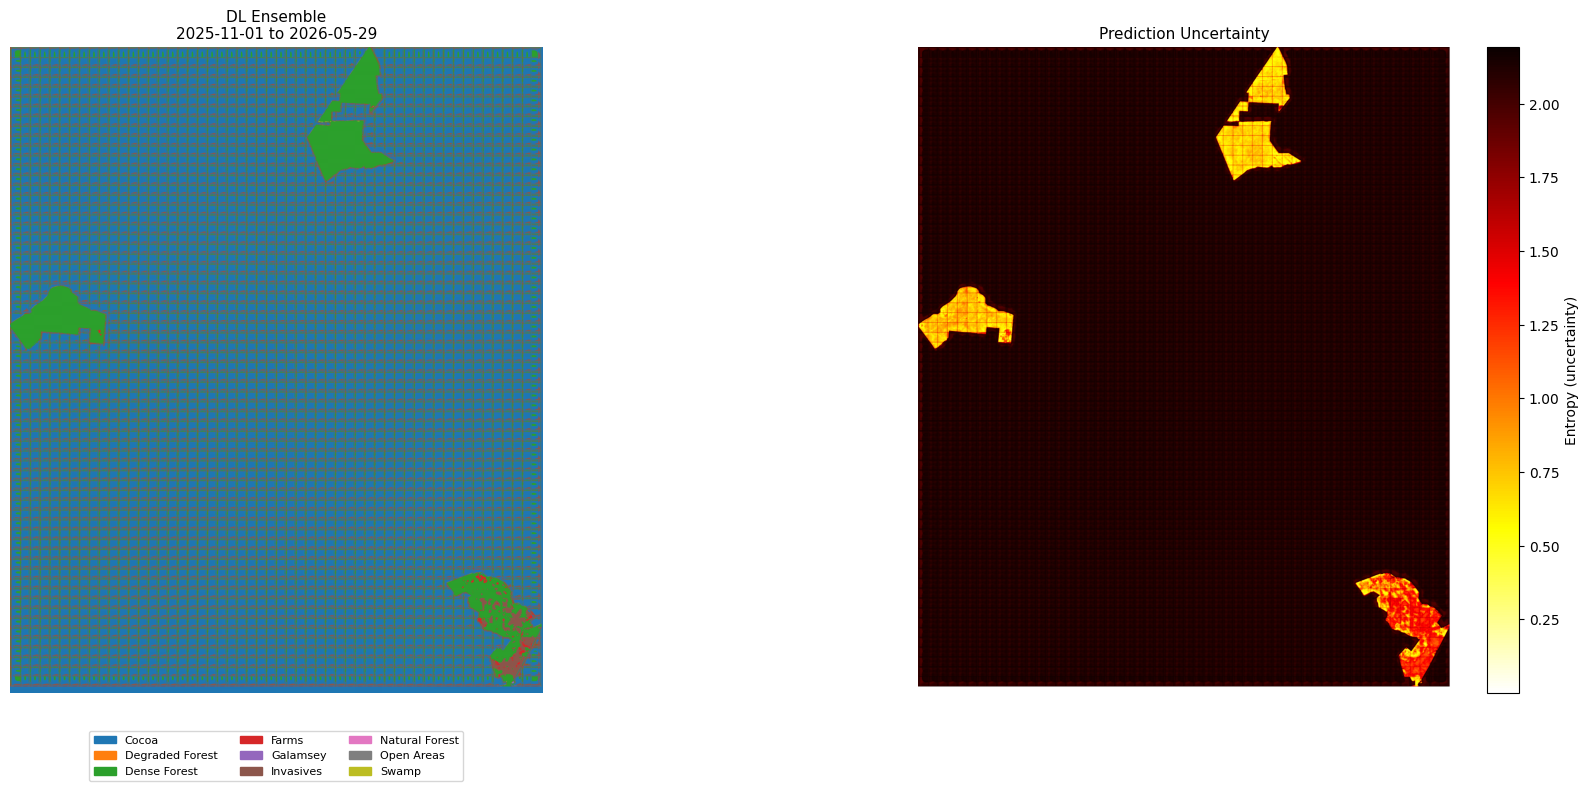

   Uploaded: phase2_s1_s2_features_new_map.png

──────────────────────────────────────────────────────
  Class                       Patches   Area (ha)  % Total
──────────────────────────────────────────────────────
  Cocoa                            61   414,027.4    71.1%  ████████████████████████████
  Degraded Forest                   2         2.6     0.0%  
  Dense Forest                  7,227    93,303.4    16.0%  ██████
  Farms                         9,651    18,512.3     3.2%  █
  Galamsey                         65       120.5     0.0%  
  Invasives                    13,339    56,205.8     9.7%  ███
  Open Areas                        1         1.3     0.0%  
  Swamp                            56        40.3     0.0%  
──────────────────────────────────────────────────────
  TOTAL                        30,402   582,213.6  100.0%

OK Results in Drive/NewImage_Results/


In [8]:
# CELL 8 -- Post-process, vectorise, visualise, and upload

def _absorb_small(arr, mmu):
    nodata = (arr == 255)
    small  = np.zeros(arr.shape, dtype=bool)
    for v in np.unique(arr[~nodata]):
        lbl, n = nd_label(arr == v)
        if n == 0:
            continue
        sizes     = np.bincount(lbl.ravel())       # sizes[i] = px count of region i
        small_ids = np.where(sizes[1:] < mmu)[0] + 1  # 1-indexed region ids
        if small_ids.size:
            small |= np.isin(lbl, small_ids)
    fill = small & ~nodata
    if not fill.any():
        return arr
    _, idx = distance_transform_edt(small | nodata, return_indices=True)
    out = arr.copy()
    rows, cols = np.where(fill)
    out[rows, cols] = arr[idx[0][rows, cols], idx[1][rows, cols]]
    print(f'   Absorbed {fill.sum():,} px')
    return out


px_area   = abs(meta['transform'].a * meta['transform'].e)
mmu_ha    = NI_CFG['mmu_pixels'] * px_area / 10_000
crs_str   = meta['crs']
transform = meta['transform']

print(f'Step 1 -- Majority filter (radius={NI_CFG["majority_radius"]} px)...')
smoothed = majority_filter_sk(pred_map.astype(np.uint8), disk(NI_CFG['majority_radius']))

print(f'Step 2 -- MMU absorption ({NI_CFG["mmu_pixels"]} px = {mmu_ha:.4f} ha)...')
smoothed = _absorb_small(smoothed, NI_CFG['mmu_pixels'])

print('Step 3 -- Vectorising...')
valid    = (smoothed != 255).astype(np.uint8)
records  = [{'geometry': shapely_shape(g), 'class_id': int(v)}
            for g, v in rasterio_shapes(smoothed, mask=valid, transform=transform)]
gdf      = gpd.GeoDataFrame(records, crs=crs_str)
print(f'   Raw patches: {len(gdf):,}')

print(f'Step 4 -- Simplifying ({NI_CFG["simplify_tol"]} m)...')
gdf['geometry']    = gdf.geometry.simplify(NI_CFG['simplify_tol'], preserve_topology=True)
gdf['class_name']  = gdf['class_id'].apply(lambda i: CLASS_NAMES[i]  if i < NUM_CLASSES else 'Unknown')
gdf['class_color'] = gdf['class_id'].apply(lambda i: CLASS_COLORS[i] if i < NUM_CLASSES else '#888888')
gdf['area_ha']     = gdf.to_crs('EPSG:32630').geometry.area / 10_000

print('Step 5 -- Dissolving by class...')
dissolved = gdf.dissolve(by='class_id', aggfunc={'area_ha': 'sum'}).reset_index()
dissolved['class_name']  = dissolved['class_id'].apply(lambda i: CLASS_NAMES[i]  if i < NUM_CLASSES else 'Unknown')
dissolved['class_color'] = dissolved['class_id'].apply(lambda i: CLASS_COLORS[i] if i < NUM_CLASSES else '#888888')
dissolved['geometry']    = dissolved.geometry.simplify(NI_CFG['simplify_tol'], preserve_topology=True)

gpkg_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_lulc.gpkg')
gdf.to_file(       gpkg_out, layer='lulc_patches',  driver='GPKG')
dissolved.to_file( gpkg_out, layer='lulc_by_class', driver='GPKG')
drive_upload(gpkg_out, subfolder='NewImage_Results')

# Visualise
cmap_ni  = mcolors.ListedColormap(CLASS_COLORS)
legend_h = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(pred_map, cmap=cmap_ni, vmin=0, vmax=NUM_CLASSES - 1)
axes[0].set_title(f'DL Ensemble\n{NI_CFG["start_date"]} to {NI_CFG["end_date"]}', fontsize=11)
axes[0].legend(handles=legend_h, bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=3, fontsize=8)
axes[0].axis('off')
unc_img = axes[1].imshow(entropy, cmap='hot_r')
plt.colorbar(unc_img, ax=axes[1], fraction=0.046, pad=0.04, label='Entropy (uncertainty)')
axes[1].set_title('Prediction Uncertainty', fontsize=11)
axes[1].axis('off')
plt.tight_layout()
png_out = str(NI_CFG['output_dir'] / f'{NI_CFG["export_prefix"]}_map.png')
plt.savefig(png_out, dpi=200, bbox_inches='tight'); plt.show()
drive_upload(png_out, subfolder='NewImage_Results')

# Area summary
total_ha = dissolved['area_ha'].sum()
sep = chr(9472) * 54
print(f'\n{sep}')
print('  {:<26}  {:>7}  {:>10}  {:>7}'.format('Class', 'Patches', 'Area (ha)', '% Total'))
print(sep)
for _, row in dissolved.sort_values('class_id').iterrows():
    pct = row['area_ha'] / total_ha * 100
    n   = (gdf['class_id'] == row['class_id']).sum()
    print('  {:<26}  {:>7,}  {:>10,.1f}  {:>6.1f}%  {}'.format(
        row['class_name'], n, row['area_ha'], pct, chr(9608) * int(pct / 2.5)))
print(sep)
print('  {:<26}  {:>7,}  {:>10,.1f}  100.0%'.format('TOTAL', len(gdf), total_ha))
print(f'\nOK Results in Drive/NewImage_Results/')
